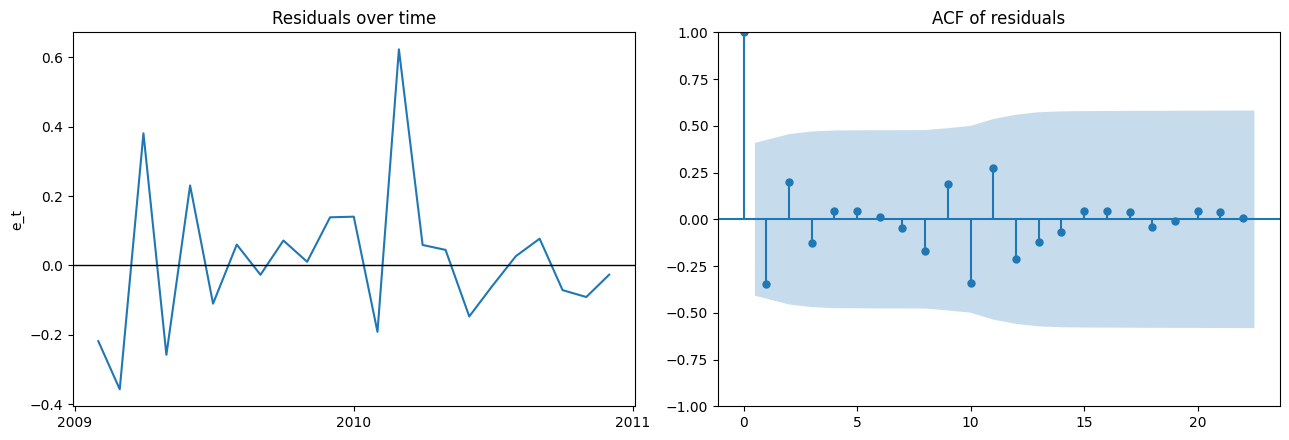

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf

# Load data
base_dir = Path.cwd()
file_path = base_dir / "datasolar.csv"
if not file_path.exists():
    file_path = base_dir / "Assignment3" / "datasolar.csv"

df = pd.read_csv(file_path)
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").set_index("date")

# Build residuals from the given model
mu = 5.72
X = np.log(df["power"].astype(float)) - mu
X_hat = 0.38 * X.shift(1) + 0.94 * X.shift(12) - 0.3572 * X.shift(13)
resid = (X - X_hat).dropna()

# Plot only: residual line plot and ACF side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(resid.index, resid.values, color="tab:blue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals over time")
axes[0].set_ylabel("e_t")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plot_acf(resid, lags=min(24, len(resid) - 1), ax=axes[1])
axes[1].set_title("ACF of residuals")

plt.tight_layout()
plt.show()

In [11]:
# Sign-changing test (runs test using residual signs)
signs = np.sign(resid.values)
signs = signs[signs != 0]  # remove exact zeros

n = len(signs)
n_pos = int((signs > 0).sum())
n_neg = int((signs < 0).sum())

if n < 2 or n_pos == 0 or n_neg == 0:
    print("Sign-changing test not applicable (insufficient sign variation).")
else:
    runs = 1 + np.sum(signs[1:] != signs[:-1])
    expected_runs = (2 * n_pos * n_neg) / n + 1
    var_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n)) / (n**2 * (n - 1))
    z = (runs - expected_runs) / np.sqrt(var_runs)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    print(f"n={n}, n_pos={n_pos}, n_neg={n_neg}")
    print(f"Observed runs: {runs}")
    print(f"Expected runs under randomness: {expected_runs:.3f}")
    print(f"Z statistic: {z:.3f}")
    print(f"Two-sided p-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion (5%): sign changes are consistent with randomness.")
    else:
        print("Conclusion (5%): sign changes are not random (possible dependence).")

n=23, n_pos=12, n_neg=11
Observed runs: 13
Expected runs under randomness: 12.478
Z statistic: 0.223
Two-sided p-value: 0.8234
Conclusion (5%): sign changes are consistent with randomness.
